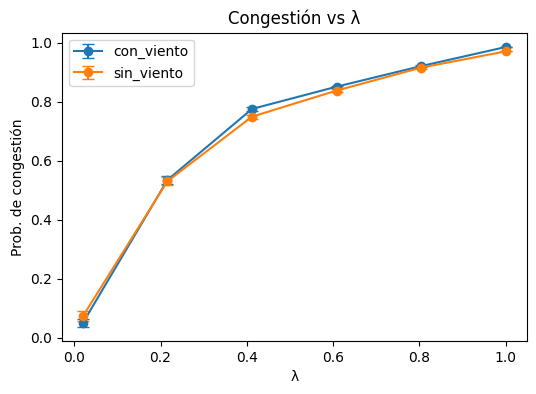

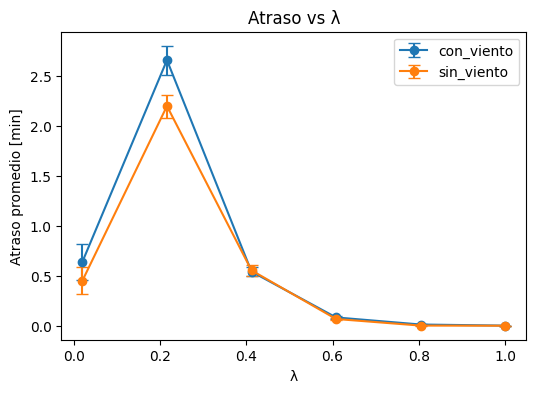

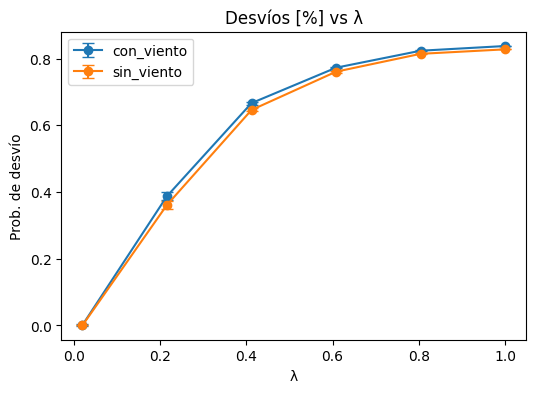

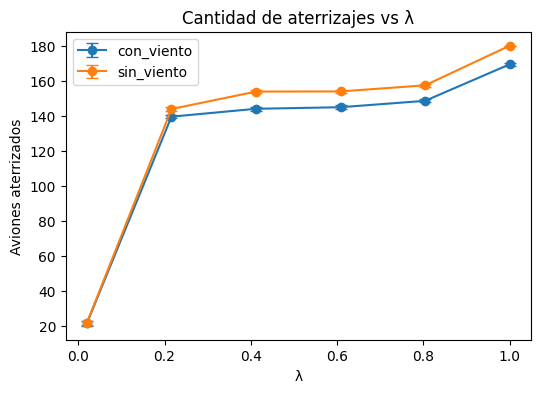

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from main import Simulador, SimuladorViento

def experimento_comparativo(lams, reps=40, minutos=18*60, seed=50):
    rng = np.random.default_rng(seed)
    registros = []

    for lam in lams:
        for modelo_tipo in ["sin_viento", "con_viento"]:
            atrasos, desv, prob_congest = [], [], []
            aterrizados, desviados_abs = [], []

            for _ in range(reps):
                if modelo_tipo == "sin_viento":
                    sim = Simulador(seed=rng.integers(1e9))
                else:
                    sim = SimuladorViento(seed=rng.integers(1e9))

                sim.simular_dia(lam, minutos)

                # atraso promedio y desviados relativos
                atrasos.append(np.mean([a.retraso for a in sim.finalizados]))
                desv.append(sum(a.estado == "DESVIADO" for a in sim.finalizados) / len(sim.finalizados))

                # cantidad de aterrizados y desviados absolutos
                aterrizados.append(sum(a.estado == "ATERRIZADO" for a in sim.finalizados))
                desviados_abs.append(sum(a.estado == "DESVIADO" for a in sim.finalizados))

                # probabilidad de congestión
                congestionados = sum(getattr(a, "congestionado", False) for a in sim.finalizados)
                total_aviones = len(sim.finalizados)
                prob_congest.append(congestionados / total_aviones if total_aviones > 0 else 0)

            registros.append({
                "lambda": lam,
                "modelo": modelo_tipo,
                "atraso_prom": np.mean(atrasos),
                "ic_atraso": 1.96 * np.std(atrasos, ddof=1) / np.sqrt(reps),
                "pct_desv": np.mean(desv),
                "ic_desv": 1.96 * np.std(desv, ddof=1) / np.sqrt(reps),
                "prob_congest": np.mean(prob_congest),
                "ic_prob_congest": 1.96 * np.std(prob_congest, ddof=1) / np.sqrt(reps),
                "landed_prom": np.mean(aterrizados),
                "landed_ic": 1.96 * np.std(aterrizados, ddof=1) / np.sqrt(reps),
                "desv_abs_prom": np.mean(desviados_abs),
                "desv_abs_ic": 1.96 * np.std(desviados_abs, ddof=1) / np.sqrt(reps),
            })

    return pd.DataFrame(registros)


# =========================
# Ejecutar experimento
# =========================
lams = np.linspace(0.02, 1, 6)
df_comp = experimento_comparativo(lams, reps=40)


# =========================
# Gráfico: Congestión
# =========================
plt.figure(figsize=(6,4))
for modelo, g in df_comp.groupby("modelo"):
    plt.errorbar(g["lambda"], g["prob_congest"],
                 yerr=g["ic_prob_congest"], fmt='-o',
                 capsize=4, label=modelo)
plt.xlabel("λ")
plt.ylabel("Prob. de congestión")
plt.title("Congestión vs λ")
plt.legend()
plt.show()


# =========================
# Gráfico: Atraso
# =========================
plt.figure(figsize=(6,4))
for modelo, g in df_comp.groupby("modelo"):
    plt.errorbar(g["lambda"], g["atraso_prom"],
                 yerr=g["ic_atraso"], fmt='-o',
                 capsize=4, label=modelo)
plt.xlabel("λ")
plt.ylabel("Atraso promedio [min]")
plt.title("Atraso vs λ")
plt.legend()
plt.show()


# =========================
# Gráfico: Desvíos (%)
# =========================
plt.figure(figsize=(6,4))
for modelo, g in df_comp.groupby("modelo"):
    plt.errorbar(g["lambda"], g["pct_desv"],
                 yerr=g["ic_desv"], fmt='-o',
                 capsize=4, label=modelo)
plt.xlabel("λ")
plt.ylabel("Prob. de desvío")
plt.title("Desvíos [%] vs λ")
plt.legend()
plt.show()


# =========================
# Gráfico: Cantidad de aterrizajes
# =========================
plt.figure(figsize=(6,4))
for modelo, g in df_comp.groupby("modelo"):
    plt.errorbar(g["lambda"], g["landed_prom"],
                 yerr=g["landed_ic"], fmt='-o',
                 capsize=4, label=modelo)
plt.xlabel("λ")
plt.ylabel("Aviones aterrizados")
plt.title("Cantidad de aterrizajes vs λ")
plt.legend()
plt.show()




In [17]:
# =========================
# Tabla resumen
# =========================
tabla_resumen = df_comp.pivot_table(
    index="lambda",
    columns="modelo",
    values=["landed_prom", "desv_abs_prom"],
    aggfunc="first"
)

# Redondeamos para que quede prolijo
tabla_resumen = tabla_resumen.round(2)

print("Tabla comparativa: Aterrizajes y Desvíos absolutos")
display(tabla_resumen)


Tabla comparativa: Aterrizajes y Desvíos absolutos


desv_abs_prom            landed_prom           
modelo    con_viento sin_viento  con_viento sin_viento
lambda                                                
0.020           0.02       0.00       21.48      21.78
0.216          89.10      82.25      139.48     143.85
0.412         288.65     281.70      143.98     153.80
0.608         493.65     490.60      144.88     153.90
0.804         695.22     691.85      148.52     157.38
1.000         876.55     867.00      169.38     180.00

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from main import Simulador, SimuladorViento

def experimento_comparativo(lams, reps=40, minutos=18*60, seed=42):
    rng = np.random.default_rng(seed)
    registros = []

    for lam in lams:
        for modelo_tipo in ["sin_viento", "con_viento"]:
            atrasos, desv, prob_congest = [], [], []

            for _ in range(reps):
                if modelo_tipo == "sin_viento":
                    sim = Simulador(seed=rng.integers(1e9))
                else:
                    sim = SimuladorViento(seed=rng.integers(1e9))

                sim.simular_dia(lam, minutos)

                # atraso promedio y desviados
                atrasos.append(np.mean([a.retraso for a in sim.finalizados]))
                desv.append(sum(a.estado=="DESVIADO" for a in sim.finalizados)/len(sim.finalizados))

                # probabilidad de congestión
                congestionados = sum(a.congestionado for a in sim.finalizados)
                total_aviones = len(sim.finalizados)
                prob_congest.append(congestionados / total_aviones if total_aviones > 0 else 0)

            registros.append({
                "lambda": lam,
                "modelo": modelo_tipo,
                "atraso_prom": np.mean(atrasos),
                "ic_atraso": 1.96*np.std(atrasos, ddof=1)/np.sqrt(reps),
                "pct_desv": np.mean(desv),
                "ic_desv": 1.96*np.std(desv, ddof=1)/np.sqrt(reps),
                "prob_congest": np.mean(prob_congest),
                "ic_prob_congest": 1.96*np.std(prob_congest, ddof=1)/np.sqrt(reps)
            })

    return pd.DataFrame(registros)


# =========================
# Ejecutar experimento con tus λ
# =========================
lams = [1/60, 0.2, 0.4, 0.6, 0.8, 1.0]
df_comp = experimento_comparativo(lams, reps=40)

# =========================
# Tabla resumen con IC 95%
# =========================
df_tabla = df_comp.copy().rename(columns={
    "lambda": "λ",
    "modelo": "Tipo",
    "atraso_prom": "Atraso (prom)",
    "ic_atraso": "Atraso (±err)",
    "pct_desv": "Desvíos (prom)",
    "ic_desv": "Desvíos (±err)",
    "prob_congest": "Congestión (prom)",
    "ic_prob_congest": "Congestión (±err)"
})

# Intervalos explícitos
df_tabla["Atraso [IC95%]"] = df_tabla.apply(
    lambda r: f"[{r['Atraso (prom)']-r['Atraso (±err)']:.2f}, {r['Atraso (prom)']+r['Atraso (±err)']:.2f}]", axis=1
)
df_tabla["Desvíos [IC95%]"] = df_tabla.apply(
    lambda r: f"[{100*(r['Desvíos (prom)']-r['Desvíos (±err)']):.1f}%, {100*(r['Desvíos (prom)']+r['Desvíos (±err)']):.1f}%]", axis=1
)
df_tabla["Congestión [IC95%]"] = df_tabla.apply(
    lambda r: f"[{100*(r['Congestión (prom)']-r['Congestión (±err)']):.1f}%, {100*(r['Congestión (prom)']+r['Congestión (±err)']):.1f}%]", axis=1
)

# Reordenar
df_tabla = df_tabla[[
    "λ", "Tipo",
    "Atraso (prom)", "Atraso (±err)", "Atraso [IC95%]",
    "Desvíos (prom)", "Desvíos (±err)", "Desvíos [IC95%]",
    "Congestión (prom)", "Congestión (±err)", "Congestión [IC95%]"
]].sort_values(by=["λ","Tipo"]).reset_index(drop=True)

print("\n=== Resumen de métricas con intervalos de confianza (95%) ===")
print(df_tabla.to_string(index=False))





=== Resumen de métricas con intervalos de confianza (95%) ===
       λ       Tipo  Atraso (prom)  Atraso (±err) Atraso [IC95%]  Desvíos (prom)  Desvíos (±err) Desvíos [IC95%]  Congestión (prom)  Congestión (±err) Congestión [IC95%]
0.016667 con_viento       0.617419       0.174151   [0.44, 0.79]        0.001136        0.002227   [-0.1%, 0.3%]           0.038135       1.171928e-02       [2.6%, 5.0%]
0.016667 sin_viento       0.347786       0.144469   [0.20, 0.49]        0.000000        0.000000    [0.0%, 0.0%]           0.061970       1.606041e-02       [4.6%, 7.8%]
0.200000 con_viento       2.842068       0.157045   [2.69, 3.00]        0.349622        0.011962  [33.8%, 36.2%]           0.505718       1.404864e-02     [49.2%, 52.0%]
0.200000 sin_viento       2.309114       0.120652   [2.19, 2.43]        0.321508        0.014726  [30.7%, 33.6%]           0.505316       1.460130e-02     [49.1%, 52.0%]
0.400000 con_viento       0.593616       0.049269   [0.54, 0.64]        0.655127       

In [9]:
def diferencias_legibles(df, lams=[0.02, 0.1, 0.2, 0.5, 1.0], tol=1e-9):
    """
    Calcula diferencias absolutas y porcentuales legibles entre con_viento y sin_viento.
    """
    filas = []
    for lam in lams:
        base = df[(np.isclose(df["lambda"], lam, atol=1e-6)) & (df["modelo"]=="sin_viento")]
        viento = df[(np.isclose(df["lambda"], lam, atol=1e-6)) & (df["modelo"]=="con_viento")]
        if base.empty or viento.empty:
            continue
        base, viento = base.iloc[0], viento.iloc[0]

        def dif_abs_rel(v_base, v_viento):
            diff_abs = v_viento - v_base
            if abs(v_base) < tol:   # si el denominador es casi 0 → porcentaje no tiene sentido
                diff_rel = "N/A"
            else:
                diff_rel = f"{100*diff_abs/v_base:.2f}%"
            return round(diff_abs, 3), diff_rel

        atraso_abs, atraso_rel = dif_abs_rel(base["atraso_prom"], viento["atraso_prom"])
        desv_abs, desv_rel = dif_abs_rel(base["pct_desv"], viento["pct_desv"])
        cong_abs, cong_rel = dif_abs_rel(base["prob_congest"], viento["prob_congest"])

        filas.append({
            "λ": lam,
            "Δ Atraso (abs)": atraso_abs,
            "Δ Atraso (%)": atraso_rel,
            "Δ Desvíos (abs)": round(desv_abs*100, 2),   # en %
            "Δ Desvíos (%)": desv_rel,
            "Δ Congestión (abs)": round(cong_abs*100, 2), # en %
            "Δ Congestión (%)": cong_rel
        })

    return pd.DataFrame(filas)

# =========================
# Ejecutar diferencias
# =========================
df_difs_legible = diferencias_legibles(df_comp, lams=[0.02, 0.1, 0.2, 0.5, 1.0])

print("\n=== Diferencias legibles (con_viento vs sin_viento) ===")
print(df_difs_legible.to_string(index=False))



=== Diferencias legibles (con_viento vs sin_viento) ===
   λ  Δ Atraso (abs) Δ Atraso (%)  Δ Desvíos (abs) Δ Desvíos (%)  Δ Congestión (abs) Δ Congestión (%)
0.02           0.189       41.95%              0.1           N/A                -2.3          -31.15%
0.10           0.811       39.67%              1.6        22.30%                -0.7           -2.39%
0.20           0.527       22.12%              2.4         7.47%                -0.3           -0.63%
0.50           0.000        0.11%              1.7         2.38%                 0.9            1.09%
1.00           0.001          N/A              1.1         1.28%                 1.4            1.43%
